# VGSOT Simulation – API Guide

This notebook focuses on the **real parameter entry points** used by the project:

1. **High-level case APIs** accept a `Config` object.
2. **Default values live in `configs.py` dataclasses**.
3. Users can either:
   - run with the default config,
   - inspect the default values,
   - override selected fields,
   - or drop down to low-level APIs for full control.

> Recommended workflow: start from a case API + default `Config`, then customize only the fields you need.

## 0. Common imports

In [17]:
from pathlib import Path
from pprint import pprint
from dataclasses import fields, is_dataclass

import matplotlib.pyplot as plt
import numpy as np

from vgsot_sim import (
    config_to_params,
    save_single_plot,
    save_three_panel_plot,
    save_two_panel_plot,
    ensure_result_dir,

    PhysicalConstantsConfig,

    TerminalVoltageControlConfig,
    SotOnlyConstantCurrentConfig,
    SotSwitchingNoVcmaConfig,
    SerSotNoVcmaThermalConfig,
    VcmaAssistedSwitchingIsotSweepConfig,
    VcmaAssistedSwitchingVmtjSweepConfig,
    OptimizedVgsotSwitchingConfig,
    SerOptimizedVgsotConfig,

    terminal_voltage_control,
    sot_only_constant_current,
    sot_switching_no_vcma,
    vcma_assisted_switching_isot_sweep,
    vcma_assisted_switching_vmtj_sweep,
    optimized_vgsot_switching,
    ser_sot_no_vcma_thermal,
    ser_optimized_vgsot,

    run_piecewise_direct_excitation,
    run_two_pulse_optimized,
)

OUT_DIR = ensure_result_dir("result_notebook")
print("Output directory:", OUT_DIR)

Output directory: result_notebook


## 1. How to expose default values from a Config

Every high-level case API uses a dataclass-style config.  
The easiest ways to inspect defaults are:

- print the config object,
- convert it to a dictionary with `config_to_params(...)`,
- or iterate over dataclass fields.

In [27]:
cfg = SerSotNoVcmaThermalConfig()
print(cfg)

SerSotNoVcmaThermalConfig(i_sot_list=(-0.0001, -9.8e-05, -9.6e-05, -9.4e-05, -9.2e-05, -9e-05), trials=1000, sim_start_step=1, sim_mid1_step=2000, sim_end_step=5000, pap=1, non=1, v_mtj=0.0, vnv=0, r_sot_fl_dl=0.0, target_mz=-1.0, failure_tol=0.1, constants=PhysicalConstantsConfig(u0=1.256637e-06, e=1.6e-19, h_bar=1.054e-34, uB=9.274e-24, kb=1.38e-23, m=9.11e-31, l=6e-08, w=5e-08, d=3e-09, rho=2.78e-06, Ki=0.00032, Ms=625000.0, beta=6e-14, tf=1.1e-09, tox=1.4e-09, D=5e-08, T=300, alpha=0.05, t_step=1e-12, Vh=0.5, P=0.58, theta_SH=0.25, phi_bar=0.4, TMR=1.0, RA=6.5e-10))


## 2. Default config vs custom config

### 2.1 Run with default config

In [4]:
res_default = sot_only_constant_current()
print(type(res_default).__name__)
print("time points:", res_default.time_s.shape)

direct_excitation: 100%|███████████████████████████████████| 5000/5000 [00:00<00:00, 17620.08it/s]

SimResult
time points: (5001,)


### 2.2 Override only the fields you care about

The rest stay at their defaults.

In [5]:
cfg_custom = SotOnlyConstantCurrentConfig(
    i_sot_stage1=-105e-6,
    sim_mid1_step=1800,
    sim_end_step=4500,
    pap=1,
)

print(cfg_custom)
res_custom = sot_only_constant_current(cfg_custom)
print("custom result points:", res_custom.time_s.shape)

SotOnlyConstantCurrentConfig(sim_start_step=1, sim_mid1_step=1800, sim_end_step=4500, pap=1, i_sot_stage1=-0.000105, i_sot_stage2=0.0, v_mtj_stage1=0.0, v_mtj_stage2=0.0, vnv=1, non=1, r_sot_fl_dl=0.83, tick_spacing_s=5e-10, constants=PhysicalConstantsConfig(u0=1.256637e-06, e=1.6e-19, h_bar=1.054e-34, uB=9.274e-24, kb=1.38e-23, m=9.11e-31, l=6e-08, w=5e-08, d=3e-09, rho=2.78e-06, Ki=0.00032, Ms=625000.0, beta=6e-14, tf=1.1e-09, tox=1.4e-09, D=5e-08, T=300, alpha=0.05, t_step=1e-12, Vh=0.5, P=0.58, theta_SH=0.25, phi_bar=0.4, TMR=1.0, RA=6.5e-10))


direct_excitation: 100%|███████████████████████████████████| 4500/4500 [00:00<00:00, 22486.54it/s]

custom result points: (4501,)


### 2.3 Customizing Physical Constants
the physical constants are exposed through `PhysicalConstantsConfig`, so users can:

- inspect all available constants,
- understand what each constant means,
- override only the constants they want to change,
- and pass the customized constants into a simulation config.

This is useful when you want to study material variation, geometry scaling, temperature dependence, VCMA strength, or numerical time-step sensitivity.

In [83]:
from vgsot_sim import PhysicalConstantsConfig


# Default constants (reference)
const_default = PhysicalConstantsConfig()
print("const_default\n", const_default)


# Fully customized constants (all parameters exposed)
const_modified = PhysicalConstantsConfig(
    # ===== Elementary constants =====
    u0=12.56637e-7,     # Vacuum permeability (H/m)
    e=1.6e-19,          # Elementary charge (C)
    h_bar=1.054e-34,    # Reduced Planck constant (J·s)
    uB=9.274e-24,       # Bohr magneton (J/T)
    kb=1.38e-23,        # Boltzmann constant (J/K)
    m=9.11e-31,         # Electron mass (kg)

    # ===== Geometry / electronic parameters =====
    # R_SOT = 776Ω
    l=240e-9,            # SOT channel length (m)
    w=200e-9,            # Device width (m)
    d=4.3e-9,            # SOT thickness (m)
    rho=278e-8,          # Resistivity (Ω·m)

    # ===== Magnetic / material parameters =====
    Ki=0.32e-3,         # Interfacial anisotropy energy density (J/m^2)
    Ms=0.625e6,         # Saturation magnetization (A/m)
    beta=60e-15,        # VCMA coefficient (J/V·m)
    tf=1.1e-9,          # Free-layer thickness (m)
    tox=1.4e-9,         # Tunnel barrier thickness (m)
    D=80e-9,            # MTJ diameter (m)
    T=300,              # Temperature (K)
    alpha=0.05,         # Gilbert damping (unitless)
    t_step=1e-12,       # Simulation time step (s)

    # ===== Switching / transport parameters =====
    Vh=0.5,             # TMR half-bias voltage (V)
    P=0.58,             # Spin polarization (unitless)
    theta_SH=0.25,      # Spin Hall angle (unitless)
    phi_bar=0.4,        # Barrier height (eV)
    TMR=1.19,           # TMR ratio (unitless)
    RA=36e-12,          # Resistance-area product (Ω·m^2)
)

print("const_modified\n", const_modified)

const_default
 PhysicalConstantsConfig(u0=1.256637e-06, e=1.6e-19, h_bar=1.054e-34, uB=9.274e-24, kb=1.38e-23, m=9.11e-31, l=6e-08, w=5e-08, d=3e-09, rho=2.78e-06, Ki=0.00032, Ms=625000.0, beta=6e-14, tf=1.1e-09, tox=1.4e-09, D=5e-08, T=300, alpha=0.05, t_step=1e-12, Vh=0.5, P=0.58, theta_SH=0.25, phi_bar=0.4, TMR=1.0, RA=6.5e-10)
const_modified
 PhysicalConstantsConfig(u0=1.256637e-06, e=1.6e-19, h_bar=1.054e-34, uB=9.274e-24, kb=1.38e-23, m=9.11e-31, l=2.4e-07, w=2e-07, d=4.3e-09, rho=2.78e-06, Ki=0.00032, Ms=625000.0, beta=6e-14, tf=1.1e-09, tox=1.4e-09, D=8e-08, T=300, alpha=0.05, t_step=1e-12, Vh=0.5, P=0.58, theta_SH=0.25, phi_bar=0.4, TMR=1.19, RA=3.6e-11)


## 3. Recommended API layers

### High-level APIs
Use these for most experiments:

- `terminal_voltage_control(cfg)`
- `sot_only_constant_current(cfg)`
- `sot_switching_no_vcma(cfg)`
- `vcma_assisted_switching_isot_sweep(cfg)`
- `vcma_assisted_switching_vmtj_sweep(cfg)`
- `optimized_vgsot_switching(cfg)`
- `ser_sot_no_vcma_thermal(cfg)`
- `ser_optimized_vgsot(cfg)`

### Low-level APIs
Use these only when you want to manually define pulse timing and excitation:

- `run_piecewise_direct_excitation(...)`
- `run_two_pulse_optimized(...)`

## 4. Example: baseline SOT-only switching

This is the simplest pattern users should copy:

1. instantiate a config,
2. inspect it,
3. modify selected fields,
4. run the case.

In [69]:
print(SotOnlyConstantCurrentConfig())

SotOnlyConstantCurrentConfig(sim_start_step=1, sim_mid1_step=2000, sim_end_step=5000, pap=1, i_sot_stage1=-9.5e-05, i_sot_stage2=0.0, v_mtj_stage1=0.0, v_mtj_stage2=0.0, vnv=1, non=1, r_sot_fl_dl=0.83, tick_spacing_s=5e-10, constants=PhysicalConstantsConfig(u0=1.256637e-06, e=1.6e-19, h_bar=1.054e-34, uB=9.274e-24, kb=1.38e-23, m=9.11e-31, l=6e-08, w=5e-08, d=3e-09, rho=2.78e-06, Ki=0.00032, Ms=625000.0, beta=6e-14, tf=1.1e-09, tox=1.4e-09, D=5e-08, T=300, alpha=0.05, t_step=1e-12, Vh=0.5, P=0.58, theta_SH=0.25, phi_bar=0.4, TMR=1.0, RA=6.5e-10))


SotOnlyConstantCurrentConfig(sim_start_step=1, sim_mid1_step=1000, sim_end_step=3000, pap=1, i_sot_stage1=-0.000620433, i_sot_stage2=0.0, v_mtj_stage1=0.0, v_mtj_stage2=0.0, vnv=1, non=1, r_sot_fl_dl=0.83, tick_spacing_s=5e-10, constants=PhysicalConstantsConfig(u0=1.256637e-06, e=1.6e-19, h_bar=1.054e-34, uB=9.274e-24, kb=1.38e-23, m=9.11e-31, l=2.4e-07, w=2e-07, d=4.3e-09, rho=2.78e-06, Ki=0.00032, Ms=625000.0, beta=6e-14, tf=1.1e-09, tox=1.4e-09, D=8e-08, T=300, alpha=0.05, t_step=1e-12, Vh=0.5, P=0.58, theta_SH=0.25, phi_bar=0.4, TMR=1.19, RA=3.6e-11))


direct_excitation: 100%|███████████████████████████████████| 3000/3000 [00:00<00:00, 27208.59it/s]


Saved: result_notebook\sot_only_constant_current.png


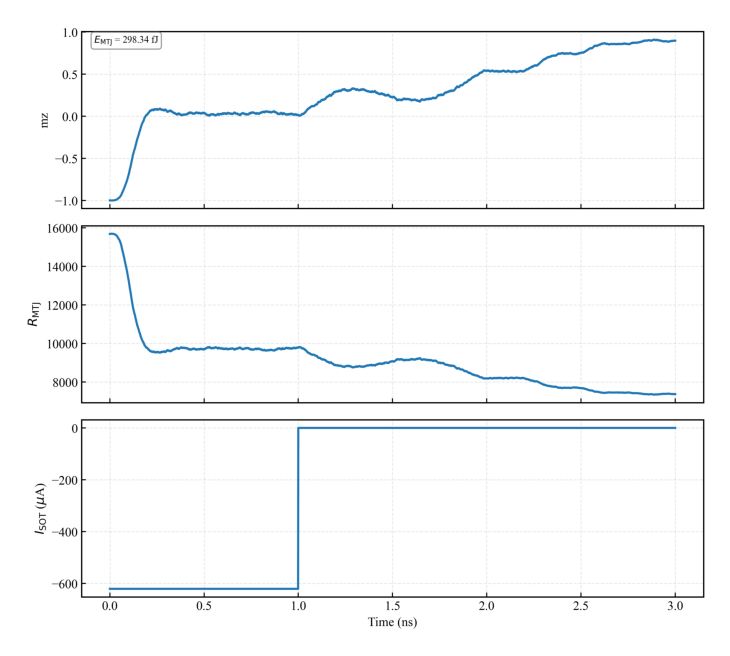

In [103]:
from vgsot_sim import (
    PhysicalConstantsConfig,
    SotOnlyConstantCurrentConfig,
    sot_only_constant_current,
)

cfg = SotOnlyConstantCurrentConfig(
    sim_mid1_step=1000,
    sim_end_step=3000,
    i_sot_stage1=-620.433e-6,
    constants=const_modified,
)
print(cfg)
res = sot_only_constant_current(cfg)

baseline_path = OUT_DIR / "sot_only_constant_current.png"
save_three_panel_plot(
    baseline_path,
    res.time_s,
    {"mz": res.mz},
    {r"$R_{\mathrm{MTJ}}$": res.r_mtj},
    {r"$I_{\mathrm{SOT}}$": res.i_sot * 1e6},
    ylabel_top="mz",
    ylabel_mid=r"$R_{\mathrm{MTJ}}$",
    ylabel_bot=r"$I_{\mathrm{SOT}}$ ($\mu$A)",
    tick_spacing_s=cfg.tick_spacing_s,
    x_is_time=True,
    energy_text=f"$E_{{\mathrm{{MTJ}}}}$ = {res.switch_energy_j * 1e15:.2f} fJ",
)

print("Saved:", baseline_path)
plt.figure(figsize=(7, 4))
img = plt.imread(baseline_path)
plt.imshow(img)
plt.axis("off")
plt.show()

## 5. Example: VCMA-assisted switching with custom sweep config

This example shows the intended user workflow for a sweep-type case:

In [96]:
cfg = VcmaAssistedSwitchingIsotSweepConfig(
    v_mtj=1.25,
    i_sot_list=[-95e-6, -70e-6, -40e-6, -20e-6, -10e-6],
    sim_end_step=10000,
    constants=const_modified,
)


res = vcma_assisted_switching_isot_sweep(cfg)
print("Available curves:", list(res.mz_curves.keys()))

direct_excitation: 100%|█████████████████████████████████| 10000/10000 [00:00<00:00, 29183.84it/s]

Available curves: ['I_SOT=-95.0uA', 'I_SOT=-70.0uA', 'I_SOT=-40.0uA', 'I_SOT=-20.0uA', 'I_SOT=-10.0uA']


Saved: result_notebook\vcma_isot_sweep.png


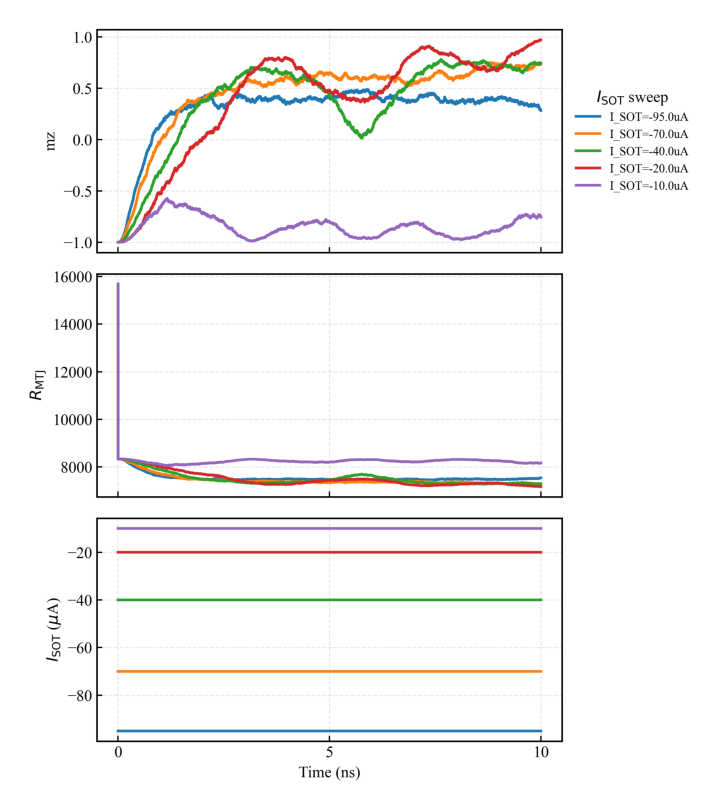

In [97]:
vcma_isot_path = OUT_DIR / "vcma_isot_sweep.png"

save_three_panel_plot(
    vcma_isot_path,
    res.time_s,
    res.mz_curves,
    res.r_mtj_curves,
    res.pulse_curves,
    ylabel_top="mz",
    ylabel_mid=r"$R_{\mathrm{MTJ}}$",
    ylabel_bot=res.pulse_ylabel,
    tick_spacing_s=cfg.tick_spacing_s,
    legend_title=r"$I_{\mathrm{SOT}}$ sweep",
    x_is_time=True,
)

print("Saved:", vcma_isot_path)
plt.figure(figsize=(8, 5))
img = plt.imread(vcma_isot_path)
plt.imshow(img)
plt.axis("off")
plt.show()

## 6. Example: optimized two-pulse VGSOT using a high-level Config

This is the preferred interface for users who want the optimized VGSOT study but **do not** want to manually manage all low-level pulse arguments.

In [94]:
cfg = OptimizedVgsotSwitchingConfig(
    v_mtj_1=1.45,
    v_mtj_2=-0.9,
    t_pairs_s=[
        (1.2e-9, 1.8e-9),
        (1.5e-9, 1.5e-9),
        (1.8e-9, 1.2e-9),
    ],
    sim_total_time_s=5e-9,
    constants=const_modified,
)

res = optimized_vgsot_switching(cfg)
print("Sweep labels:")
for k in res.mz_curves.keys():
    print(" ", k)

direct_excitation: 100%|███████████████████████████████████| 5000/5000 [00:00<00:00, 33532.01it/s]

Sweep labels:
  t1=1.20ns,t2=1.80ns
  t1=1.50ns,t2=1.50ns
  t1=1.80ns,t2=1.20ns


Saved figure to: result_notebook\optimized_vgsot_switching_demo.png


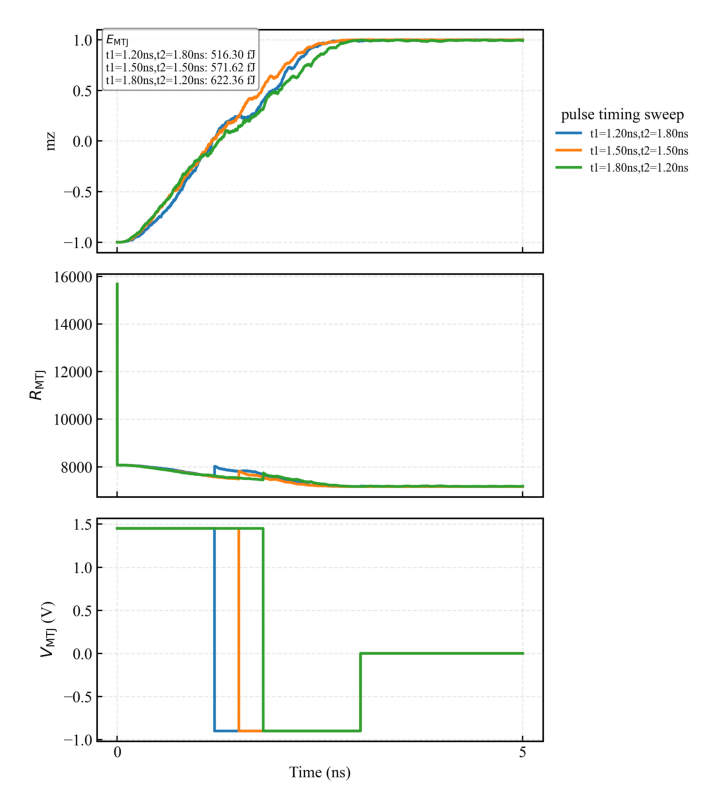

In [95]:
# Visualize mz curves for all pulse pairs
def _format_energy_fj(value_j: float) -> str:
    return f"{value_j * 1e15:.2f} fJ"

def _sweep_energy_text(values: dict[str, float]) -> str:
    lines = [r"$E_{\mathrm{MTJ}}$"]
    for label, value in values.items():
        lines.append(f"{label}: {_format_energy_fj(value)}")
    return "\n".join(lines)


optimized_vgsot_path = OUT_DIR / "optimized_vgsot_switching_demo.png"

save_three_panel_plot(
    optimized_vgsot_path,
    res.time_s,
    res.mz_curves,
    res.r_mtj_curves,
    res.pulse_curves,
    ylabel_top="mz",
    ylabel_mid=r"$R_{\mathrm{MTJ}}$",
    ylabel_bot=res.pulse_ylabel,
    tick_spacing_s=cfg.tick_spacing_s,
    legend_title="pulse timing sweep",
    x_is_time=True,
    energy_text=_sweep_energy_text(res.switch_energy_j),
)

print(f"Saved figure to: {optimized_vgsot_path}")
plt.figure(figsize=(8, 5))
img = plt.imread(optimized_vgsot_path)
plt.imshow(img)
plt.axis("off")
plt.show()

## 7. Example: SER simulation and how to customize reliability settings

This example highlights a very important documentation point:

- `trials` controls Monte Carlo sample count
- `target_mz` and `failure_tol` define the failure criterion
- `i_sot_list` defines the x-axis sweep

In [105]:
cfg = SerSotNoVcmaThermalConfig(
    i_sot_list=[-800e-6, -700e-6, -600e-6, -500e-6, -400e-6],
    sim_mid1_step=5000,
    sim_end_step=10000,
    trials=100,
    failure_tol=2e-1,
    target_mz=1,
    constants=const_modified,
)

res = ser_sot_no_vcma_thermal(cfg)
print("x:", res.x)
print("SER:", res.ser)

MC isot=-4.000e-04A: 100%|██████████████████████████████████████| 100/100 [00:31<00:00,  3.13it/s]

x: [-0.0008 -0.0007 -0.0006 -0.0005 -0.0004]
SER: [0.13 0.16 0.27 0.15 1.  ]


Saved: result_notebook\ser_sot_no_vcma_thermal.png


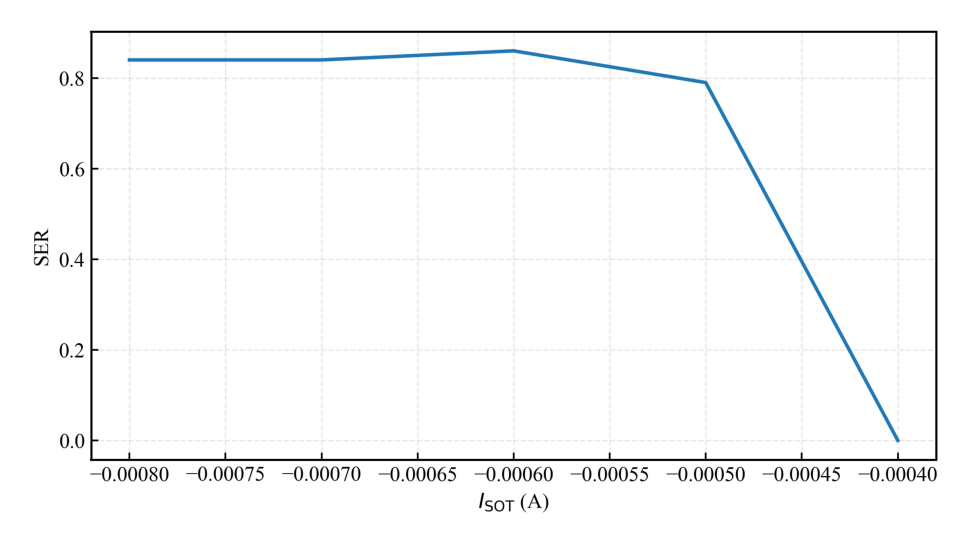

In [99]:
ser_path = OUT_DIR / "ser_sot_no_vcma_thermal.png"

save_single_plot(
    ser_path,
    res.x,
    {"SER": res.ser},
    xlabel=res.x_label,
    ylabel="SER",
    x_is_time=False,
)

print("Saved:", ser_path)
plt.figure(figsize=(6, 4))
img = plt.imread(ser_path)
plt.imshow(img)
plt.axis("off")
plt.show()

## 8. Low-level API example: full manual pulse definition

Use a low-level API only when you need direct control over stage-by-stage excitation.

This is the correct place to specify raw values such as:

- pulse timing,
- stage voltages/currents,
- STT/SOT enable flags,
- thermal noise and VCMA switches.

In [13]:
res = run_piecewise_direct_excitation(
    sim_start_step=1,
    sim_mid1_step=1500,
    sim_mid2_step=3000,
    sim_end_step=5000,
    pap=1,

    v_mtj_stage1=1.2,
    v_mtj_stage2=-0.8,
    v_mtj_stage3=0.0,

    i_sot_stage1=-90e-6,
    i_sot_stage2=0.0,
    i_sot_stage3=0.0,

    estt_stage1=0,
    esot_stage1=1,
    estt_stage2=0,
    esot_stage2=1,
    estt_stage3=0,
    esot_stage3=1,

    vnv=1,
    non=1,
    r_sot_fl_dl=0.0,
)

print(type(res).__name__)
print("time shape:", res.time_s.shape)

direct_excitation: 100%|███████████████████████████████████| 5000/5000 [00:00<00:00, 13660.26it/s]

SimResult
time shape: (5001,)


## 9. Low-level API example: two-pulse optimized interface

If you need direct control over `t1`, `t2`, and both pulses, use `run_two_pulse_optimized(...)`.

Unlike the high-level case API, this function expects you to explicitly provide the pulse parameters.

In [14]:
res = run_two_pulse_optimized(
    t1_s=1.5e-9,
    t2_s=1.5e-9,
    v_mtj_1=1.4937,
    v_mtj_2=-1.0,
    i_sot_1=-100e-6,
    i_sot_2=0.0,
    sim_total_time_s=25e-9,
    pap=1,
    non=1,
    vnv=1,
    r_sot_fl_dl=0.0,
)

print(type(res).__name__)
print("time shape:", res.time_s.shape)
print("energy (fJ):", res.switch_energy_j * 1e15)

direct_excitation: 100%|█████████████████████████████████| 25000/25000 [00:00<00:00, 25321.68it/s]

SimResult
time shape: (25001,)
energy (fJ): 30.711575973835064


## 10. Quick reference: how should users choose an API?

### Choose a high-level case API when:
- you want to reproduce a built-in experiment,
- you want sensible defaults,
- you want to customize only a few knobs.

### Choose a low-level API when:
- you need exact pulse-by-pulse control,
- you want to define stages manually,
- you are building a new experiment not covered by existing case wrappers.

## 11. Quick reference: common documentation patterns you should keep

When adding or updating docs for any new case, always include these four blocks:

1. **Default config**  
   Show `print(cfg)` or `pprint(config_to_params(cfg))`

2. **Minimal runnable example**  
   Show the default call

3. **Custom config example**  
   Override 2–4 representative fields

4. **When to use this API**  
   Explain whether it is a high-level case API or a low-level kernel

## 12. Summary

The most important thing for users to understand is:

- **Config classes are the main parameter interface**
- **Default values are defined in `configs.py`**
- **Use `config_to_params(cfg)` to expose defaults clearly**
- **Customize configs by overriding only selected fields**
- **Drop down to low-level APIs only when you need full manual control**